In [1]:
from deepspeed.profiling.flops_profiler import get_model_profile
import torch
from torch import nn

def profile(model: torch.nn.Module, input_shape: tuple[int, ...]):
    flops, macs, params = get_model_profile(model, input_shape, warm_up=10, print_profile=True, as_string=False)
    return flops

[2025-05-09 16:51:25,924] [WARNING] [real_accelerator.py:194:get_accelerator] Setting accelerator to CPU. If you have GPU or other accelerator, we were unable to detect it.
[2025-05-09 16:51:25,925] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cpu (auto detect)


/home/ron/mambaforge/envs/FlexConv/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


In [2]:
def flops_linear(input_dim, output_dim, bias=True):
    """
    Calculate the number of FLOPs for a linear layer.
    """
    flops = (input_dim + input_dim - 1) * output_dim # multiplication and accumulation for each output
    if bias:
        flops += output_dim
    return flops

in_dim = out_dim = 128
bias = True

ds_flops = profile(nn.Linear(in_dim, out_dim, bias=bias), (1, in_dim))
my_flops = flops_linear(in_dim, out_dim, bias)
print(f"Deepspeed FLOPs: {ds_flops}")
print(f"My FLOPs: {my_flops}")

[2025-05-09 16:51:26,607] [INFO] [profiler.py:1254:get_model_profile] Flops profiler warming-up...
[2025-05-09 16:51:26,650] [INFO] [profiler.py:82:start_profile] Flops profiler started

-------------------------- DeepSpeed Flops Profiler --------------------------
Profile Summary at step 10:
Notations:
data parallel size (dp_size), model parallel size(mp_size),
number of parameters (params), number of multiply-accumulate operations(MACs),
number of floating-point operations (flops), floating-point operations per second (FLOPS),
fwd latency (forward propagation latency), bwd latency (backward propagation latency),
step (weights update latency), iter latency (sum of fwd, bwd and step latency)

params per GPU:                                                         16.51 K 
params of model = params per GPU * mp_size:                             0       
fwd MACs per GPU:                                                       16.38 KMACs
fwd flops per GPU:                                  

In [3]:
def flops_mm(a_size, b_size):
    """
    Calculate the number of FLOPs for matrix multiplication.
    """
    assert a_size[1] == b_size[0], "Incompatible matrix sizes for multiplication"
    n, p = a_size
    _, m = b_size
    flops = n * (2 * p - 1) * m  # multiplication and accumulation for each output
    return flops


class MatrixMultiply(nn.Module):
    def forward(self, a, b):
        return torch.bmm(a, b)


a_size = (5, 3)
b_size = (3, 4)
ds_flops = \
get_model_profile(MatrixMultiply(), args=[torch.randn(*a_size), torch.randn(*b_size)], warm_up=10, print_profile=True,
                  as_string=False)[0]
my_flops = flops_mm(a_size, b_size)
print(f"Deepspeed FLOPs: {ds_flops}")
print(f"My FLOPs: {my_flops}")

[2025-05-09 16:51:26,681] [INFO] [profiler.py:1254:get_model_profile] Flops profiler warming-up...
[2025-05-09 16:51:26,682] [INFO] [profiler.py:82:start_profile] Flops profiler started

-------------------------- DeepSpeed Flops Profiler --------------------------
Profile Summary at step 10:
Notations:
data parallel size (dp_size), model parallel size(mp_size),
number of parameters (params), number of multiply-accumulate operations(MACs),
number of floating-point operations (flops), floating-point operations per second (FLOPS),
fwd latency (forward propagation latency), bwd latency (backward propagation latency),
step (weights update latency), iter latency (sum of fwd, bwd and step latency)

params per GPU:                                                         0       
params of model = params per GPU * mp_size:                             0       
fwd MACs per GPU:                                                       60 MACs 
fwd flops per GPU:                                     

In [4]:
def flops_conv2d(input_channels, output_channels, kernel_size, input_height, input_width, bias=True):
    """
    Calculate the number of FLOPs for a 2D convolution layer.
    """
    flops = input_channels * output_channels * (2 * (kernel_size ** 2) - 1) * input_height * input_width
    if bias:
        flops += output_channels
    return flops


input_channels = 3
output_channels = 16
kernel_size = 3
input_height = input_width = 64
bias = True

ds_flops = profile(nn.Conv2d(input_channels, output_channels, kernel_size, bias=bias),
                   (1, input_channels, input_height, input_width))
my_flops = flops_conv2d(input_channels, output_channels, kernel_size, input_height, input_width, bias)
print(f"Deepspeed FLOPs: {ds_flops}")
print(f"My FLOPs: {my_flops}")

[2025-05-09 16:51:26,733] [INFO] [profiler.py:1254:get_model_profile] Flops profiler warming-up...
[2025-05-09 16:51:26,752] [INFO] [profiler.py:82:start_profile] Flops profiler started

-------------------------- DeepSpeed Flops Profiler --------------------------
Profile Summary at step 10:
Notations:
data parallel size (dp_size), model parallel size(mp_size),
number of parameters (params), number of multiply-accumulate operations(MACs),
number of floating-point operations (flops), floating-point operations per second (FLOPS),
fwd latency (forward propagation latency), bwd latency (backward propagation latency),
step (weights update latency), iter latency (sum of fwd, bwd and step latency)

params per GPU:                                                         448     
params of model = params per GPU * mp_size:                             0       
fwd MACs per GPU:                                                       1.66 MMACs
fwd flops per GPU:                                   

In [5]:
def flops_self_attention(seq_length, embed_dim, ff_factor=4):
    """
    Calculate the number of FLOPs for a self-attention layer.
    """
    flops = 0
    # Self-attention
    # Query, Key, Value projections
    flops += seq_length * flops_linear(embed_dim, embed_dim) * 3  # Q, K, V projections
    # Attention scores
    flops += flops_mm([seq_length, embed_dim], [embed_dim, seq_length])  # QK^T
    # Scaling
    flops += seq_length ** 2
    # Softmax over rows
    flops += seq_length ** 2 # should be seq_length * (3 * seq_length - 1) due to Softmax (exp, sum, division) but seems to be optimized into one op
    # Y projection
    flops += flops_mm([seq_length, seq_length], [seq_length, embed_dim])
    # head unify
    flops += seq_length * flops_linear(embed_dim, embed_dim)

    # Feedforward
    flops += seq_length * flops_linear(embed_dim, embed_dim * ff_factor)
    flops += seq_length * flops_linear(embed_dim * ff_factor, embed_dim)

    return flops


seq_length = 128
embed_dim = 64
ff_factor = 4


class Wrapper(nn.Module):
    def __init__(self, embed_dim, ff_factor):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(embed_dim, num_heads=1)
        self.linear1 = nn.Linear(embed_dim, embed_dim * ff_factor)
        self.linear2 = nn.Linear(embed_dim * ff_factor, embed_dim)

    def forward(self, x):
        attn_output, _ = self.self_attn(x, x, x)
        x = self.linear1(attn_output)
        x = self.linear2(x)
        return x


ds_flops = get_model_profile(Wrapper(embed_dim, ff_factor), (1, seq_length, embed_dim), warm_up=10, print_profile=True,
                             as_string=False)[0]
my_flops = flops_self_attention(seq_length, embed_dim)
print(f"Deepspeed FLOPs: {ds_flops}")
print(f"My FLOPs: {my_flops}")

[2025-05-09 16:51:26,784] [INFO] [profiler.py:1254:get_model_profile] Flops profiler warming-up...
[2025-05-09 16:51:26,791] [INFO] [profiler.py:82:start_profile] Flops profiler started

-------------------------- DeepSpeed Flops Profiler --------------------------
Profile Summary at step 10:
Notations:
data parallel size (dp_size), model parallel size(mp_size),
number of parameters (params), number of multiply-accumulate operations(MACs),
number of floating-point operations (flops), floating-point operations per second (FLOPS),
fwd latency (forward propagation latency), bwd latency (backward propagation latency),
step (weights update latency), iter latency (sum of fwd, bwd and step latency)

params per GPU:                                                         49.73 K 
params of model = params per GPU * mp_size:                             0       
fwd MACs per GPU:                                                       6.31 MMACs
fwd flops per GPU:                                   

In [6]:
def flops_local_self_attention(seq_length, embed_dim, kernel_size, ff_factor=4):
    """
    Calculate the number of FLOPs for a self-attention layer.
    """
    flops = 0
    # Self-attention
    # Query, Key, Value projections
    flops += seq_length * flops_linear(embed_dim, embed_dim) * 3  # Q, K, V projections
    # Attention scores (local)
    flops += flops_mm([seq_length, embed_dim], [embed_dim, kernel_size ** 2])
    # Scaling
    flops += seq_length ** 2
    # Softmax over rows
    flops += seq_length ** 2
    # Y projection
    flops += flops_mm([seq_length, seq_length], [seq_length, embed_dim])
    # head unify
    flops += seq_length * flops_linear(embed_dim, embed_dim)

    # Feedforward
    flops += seq_length * flops_linear(embed_dim, embed_dim * ff_factor)
    flops += seq_length * flops_linear(embed_dim * ff_factor, embed_dim)

    return flops

seq_length = 4096
embed_dim = 64
kernel_size = 3
ff_factor = 4

print(flops_self_attention(seq_length, embed_dim, ff_factor))
print(flops_local_self_attention(seq_length, embed_dim, kernel_size, ff_factor))

4714135552
2588110848


In [7]:
import pandas as pd

results_df = pd.DataFrame(columns=['operation', 'kernel', 'spatial', 'flops'])
done_4_full_atn = False
for kernel_size in [3, 5, 7, 9]:
    for config in [(64, 128), (128, 64), (256, 32), (512, 16), (1024, 8), (2048, 4)]:
        n_channel, spatial_dim = config
        kernel_label = f'{kernel_size}²'
        spatial_label = f'{n_channel}x{spatial_dim}²'

        conv_flops = flops_conv2d(n_channel, n_channel, kernel_size, spatial_dim, spatial_dim)
        results_df.loc[len(results_df.index)] = ['conv', kernel_label, spatial_label, conv_flops]

        local_attn_flops = flops_local_self_attention(spatial_dim**2, n_channel, kernel_size)
        results_df.loc[len(results_df.index)] = ['local_attn', kernel_label, spatial_label, local_attn_flops]

        if not done_4_full_atn:
            full_atn_flops = flops_self_attention(spatial_dim**2, n_channel)
            results_df.loc[len(results_df.index)] = ['full_attn', '-', spatial_label, full_atn_flops]
    done_4_full_atn = True

print(results_df)

     operation kernel  spatial        flops
0         conv     3²  64x128²   1140850752
1   local_attn     3²  64x128²  36524900352
2    full_attn      -  64x128²  70597476352
3         conv     3²  128x64²   1140850816
4   local_attn     3²  128x64²   5948010496
5    full_attn      -  128x64²  10216800256
6         conv     3²  256x32²   1140850944
7   local_attn     3²  256x32²   2154028032
8    full_attn      -  256x32²   2685140992
9         conv     3²  512x16²   1140851200
10  local_attn     3²  512x16²   1680078592
11   full_attn      -  512x16²   1744764928
12        conv     3²  1024x8²   1140851712
13  local_attn     3²  1024x8²   1620123072
14   full_attn      -  1024x8²   1627328512
15        conv     3²  2048x4²   1140852736
16  local_attn     3²  2048x4²   1612218736
17   full_attn      -  2048x4²   1612677376
18        conv     5²  64x128²   3288334400
19  local_attn     5²  64x128²  36558192640
20        conv     5²  128x64²   3288334464
21  local_attn     5²  128x64²  

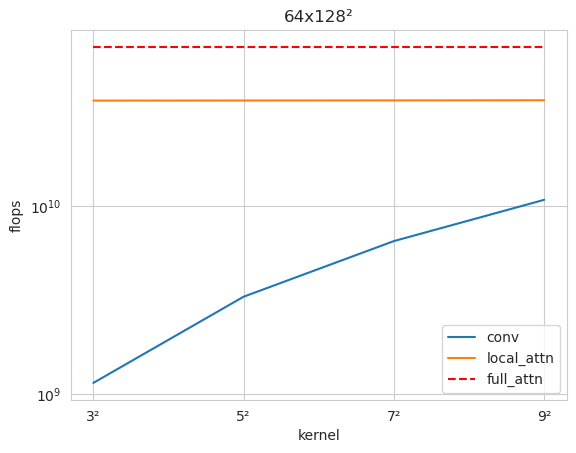

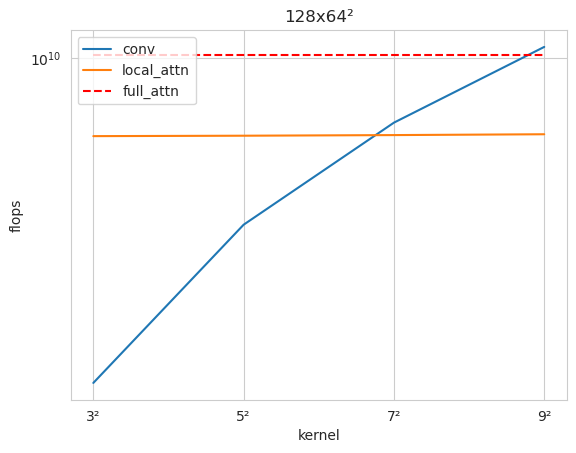

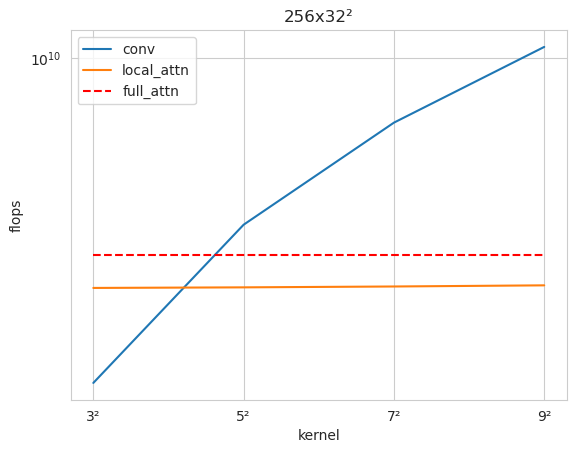

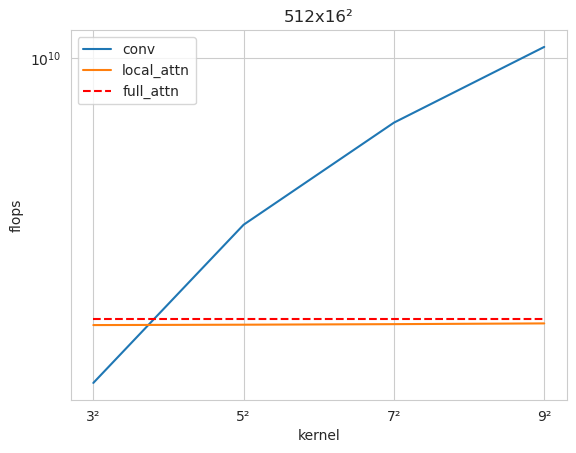

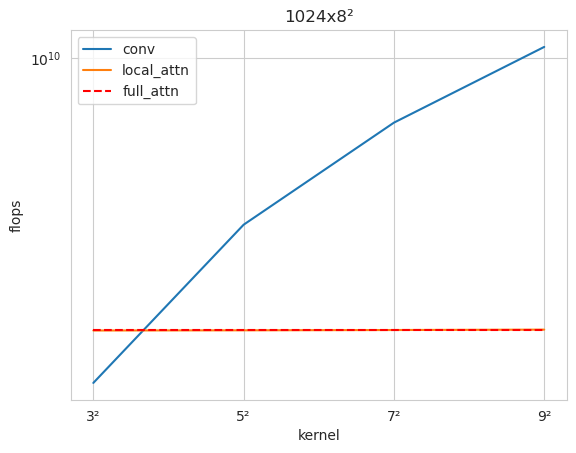

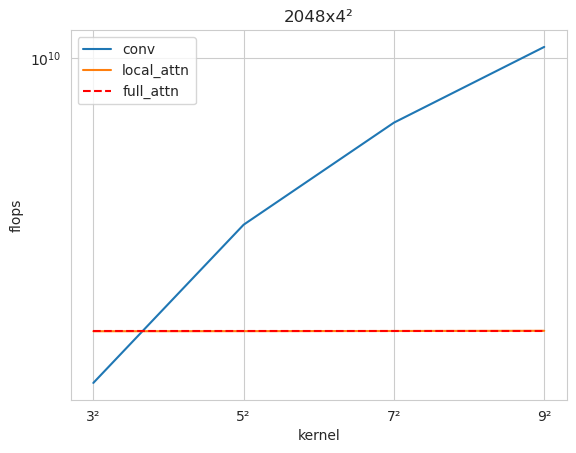

In [8]:
import seaborn as sns
from matplotlib import pyplot as plt

for spatial_dim, g_df in results_df.groupby('spatial', sort=False):
    row_full_atn = g_df[g_df['operation'] == 'full_attn']
    g_df = g_df[g_df['operation'] != 'full_attn']
    full_attn_hline_kwargs = dict(xmin=0, xmax=len(g_df['kernel'].unique()) - 1, colors='r', label='full_attn',
                                  linestyle='--')

    plt.figure()

    ln_plot_kwargs = dict(x='kernel', hue='operation', data=g_df)

    sns.lineplot(y='flops', **ln_plot_kwargs)
    plt.hlines(row_full_atn['flops'].values, **full_attn_hline_kwargs)
    plt.yscale('log')
    plt.legend()
    plt.title(spatial_dim)